In [44]:
import pandas as pd

In [45]:
trades = pd.read_csv('historical_data.csv')
sentiment = pd.read_csv('fear_greed_index.csv')

In [46]:
# Basic info
print("Trades shape:", trades.shape)
print("Sentiment shape:", sentiment.shape)

Trades shape: (211224, 16)
Sentiment shape: (2644, 4)


In [47]:
print("\nTrades columns:")
print(trades.columns)


Trades columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [48]:
print("\nSentiment columns:")
print(sentiment.columns)


Sentiment columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [49]:
# Check missing values
print("\nMissing values in trades:")
print(trades.isnull().sum())


Missing values in trades:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [50]:
print("\nMissing values in sentiment:")
print(sentiment.isnull().sum())


Missing values in sentiment:
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [51]:
# Check duplicates
print("\nDuplicate rows in trades:", trades.duplicated().sum())
print("Duplicate rows in sentiment:", sentiment.duplicated().sum())


Duplicate rows in trades: 0
Duplicate rows in sentiment: 0


In [52]:
# Convert timestamp (milliseconds → datetime)
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')

In [53]:
# Create daily trade date
trades['trade_date'] = trades['Timestamp'].dt.date

In [54]:
# Ensure numeric columns
trades['Closed PnL'] = pd.to_numeric(trades['Closed PnL'], errors='coerce')
trades['Size USD'] = pd.to_numeric(trades['Size USD'], errors='coerce')

In [55]:
# Create behavior columns
trades['is_win'] = trades['Closed PnL'] > 0
trades['is_long'] = trades['Side'].str.lower() == 'buy'

In [56]:
daily_metrics = trades.groupby(['Account', 'trade_date']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    trade_count=('Closed PnL', 'count'),
    win_rate=('is_win', 'mean'),
    avg_trade_size=('Size USD', 'mean'),
    long_ratio=('is_long', 'mean')
).reset_index()

In [57]:
print("\nDaily metrics shape:", daily_metrics.shape)
print(daily_metrics.head())


Daily metrics shape: (102, 7)
                                      Account  trade_date     daily_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27 -3.275059e+05   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19  1.927736e+06   
2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27  2.060745e+04   
3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19  1.709873e+04   
4  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-06-15  1.017915e+04   

   trade_count  win_rate  avg_trade_size  long_ratio  
0          462  0.025974    14810.891818    0.300866  
1         3356  0.405542    16345.241940    0.468415  
2          320  0.531250     2492.749906    0.453125  
3         3533  0.435041     1693.351684    0.432494  
4         3427  0.442369     1533.468395    0.403268  


In [58]:
# Keep only required columns
sentiment_clean = sentiment[['date', 'classification']].copy()

In [59]:
# Convert date
sentiment_clean['date'] = pd.to_datetime(sentiment_clean['date'])
sentiment_clean['sentiment_date'] = sentiment_clean['date'].dt.date

In [60]:
sentiment_clean = sentiment_clean[['sentiment_date', 'classification']]

In [61]:
print("\nSentiment cleaned shape:", sentiment_clean.shape)
print(sentiment_clean.head())


Sentiment cleaned shape: (2644, 2)
  sentiment_date classification
0     2018-02-01           Fear
1     2018-02-02   Extreme Fear
2     2018-02-03           Fear
3     2018-02-04   Extreme Fear
4     2018-02-05   Extreme Fear


In [62]:
merged_data = daily_metrics.merge(
    sentiment_clean,
    left_on='trade_date',
    right_on='sentiment_date',
    how='inner'
)

In [63]:
print("\nMerged data shape:", merged_data.shape)
print(merged_data.head())


Merged data shape: (77, 9)
                                      Account  trade_date     daily_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27 -3.275059e+05   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19  1.927736e+06   
2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27  2.060745e+04   
3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19  1.709873e+04   
4  0x271b280974205ca63b716753467d5a371de622ab  2024-07-03 -1.000000e+00   

   trade_count  win_rate  avg_trade_size  long_ratio sentiment_date  \
0          462  0.025974    14810.891818    0.300866     2024-10-27   
1         3356  0.405542    16345.241940    0.468415     2025-02-19   
2          320  0.531250     2492.749906    0.453125     2024-10-27   
3         3533  0.435041     1693.351684    0.432494     2025-02-19   
4            5  0.000000     6070.200000    0.400000     2024-07-03   

  classification  
0          Greed  
1           Fear  
2          Greed  
3           Fear  

In [64]:
# Normalize sentiment into Fear / Greed / Neutral

def simplify_sentiment(x):
    x = x.lower()
    if 'fear' in x:
        return 'Fear'
    elif 'greed' in x:
        return 'Greed'
    else:
        return 'Neutral'

merged_data['sentiment_group'] = merged_data['classification'].apply(simplify_sentiment)

print(merged_data['sentiment_group'].value_counts())

sentiment_group
Greed      37
Fear       32
Neutral     8
Name: count, dtype: int64


In [65]:
# Filter only Fear and Greed
fg_data = merged_data[merged_data['sentiment_group'].isin(['Fear', 'Greed'])]

performance_by_sentiment = fg_data.groupby('sentiment_group').agg(
    avg_daily_pnl=('daily_pnl', 'mean'),
    median_daily_pnl=('daily_pnl', 'median'),
    avg_win_rate=('win_rate', 'mean'),
    avg_trade_count=('trade_count', 'mean'),
    avg_trade_size=('avg_trade_size', 'mean'),
    avg_long_ratio=('long_ratio', 'mean')
)

print(performance_by_sentiment)

                 avg_daily_pnl  median_daily_pnl  avg_win_rate  \
sentiment_group                                                  
Fear             209372.662205      81389.682515      0.415878   
Greed             90988.703436      20925.513222      0.369012   

                 avg_trade_count  avg_trade_size  avg_long_ratio  
sentiment_group                                                   
Fear                 4183.468750     5926.522723        0.459352  
Greed                1168.945946     5637.302441        0.498847  


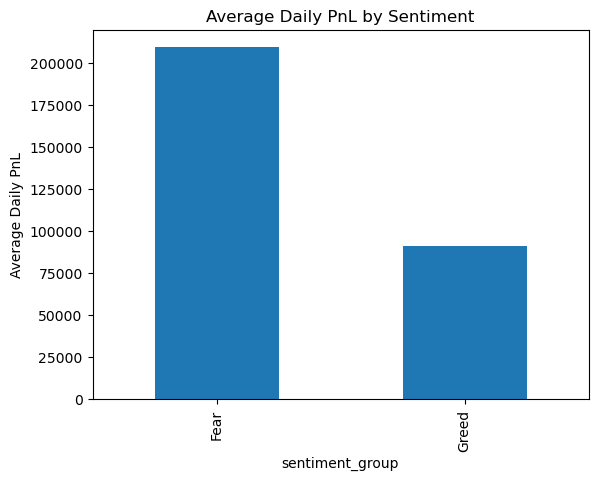

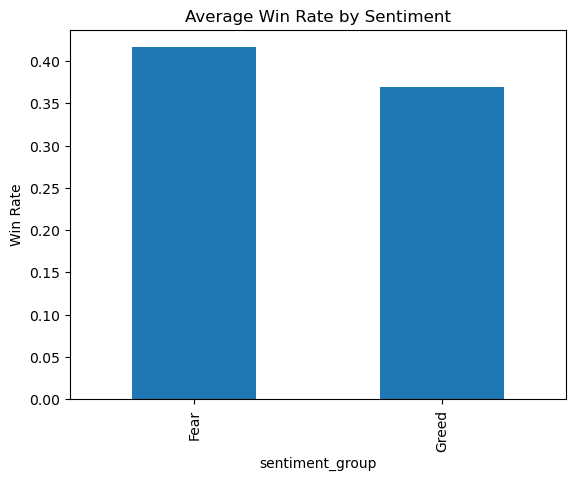

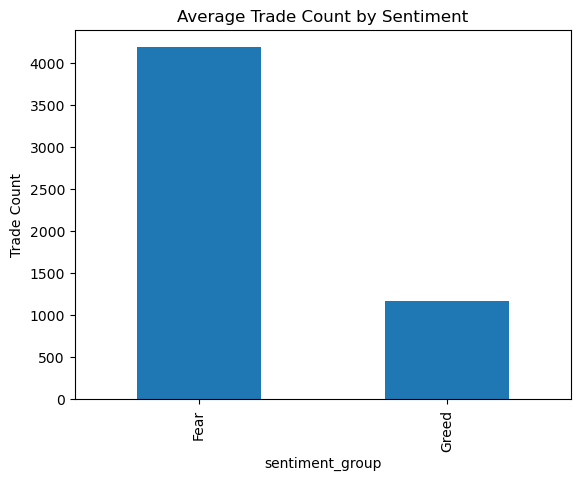

In [66]:
import matplotlib.pyplot as plt

# Average PnL comparison
performance_by_sentiment['avg_daily_pnl'].plot(kind='bar')
plt.title('Average Daily PnL by Sentiment')
plt.ylabel('Average Daily PnL')
plt.show()

# Win rate comparison
performance_by_sentiment['avg_win_rate'].plot(kind='bar')
plt.title('Average Win Rate by Sentiment')
plt.ylabel('Win Rate')
plt.show()

# Trade count comparison
performance_by_sentiment['avg_trade_count'].plot(kind='bar')
plt.title('Average Trade Count by Sentiment')
plt.ylabel('Trade Count')
plt.show()

# Methodology

1. Cleaned and aligned trade-level and sentiment datasets at daily level.
2. Aggregated trade data to account-day level to compute performance and behavior metrics.
3. Merged trader metrics with sentiment classification (Fear vs Greed).
4. Compared performance and behavior across sentiment regimes.
5. Created activity-based trader segments using median trade frequency split.

# Part B — Key Insights

## Insight 1 — Traders Perform Significantly Better During Fear Periods

Average daily PnL during Fear periods (209k) is more than 2x higher than during Greed (91k).  
Median PnL also shows a strong difference (81k vs 20k).  
Additionally, win rate is higher during Fear (0.416) compared to Greed (0.369).

**Interpretation:**  
Trader profitability improves during Fear-driven market conditions. This may be due to increased volatility creating larger price dislocations and short-term trading opportunities.

---

## Insight 2 — Trading Activity Increases Substantially During Fear

Average trade count during Fear (4183) is approximately 3.5x higher than during Greed (1168).

**Interpretation:**  
Fear periods are associated with significantly higher trading intensity. Traders appear more active and responsive during volatile market conditions.

---

## Insight 3 — Increased Long Bias During Greed Does Not Improve Performance

The average long ratio is slightly higher during Greed (0.498) compared to Fear (0.459).  
However, profitability and win rate are lower during Greed periods.

**Interpretation:**  
During Greed phases, traders exhibit a stronger long bias, but this does not translate into improved outcomes. This may indicate overconfidence or crowded positioning behavior.

In [67]:
# Calculate average trade count per trader (overall)
trader_activity = daily_metrics.groupby('Account')['trade_count'].mean().reset_index()

# Median split threshold
activity_threshold = trader_activity['trade_count'].median()

trader_activity['activity_segment'] = trader_activity['trade_count'].apply(
    lambda x: 'High Activity' if x >= activity_threshold else 'Low Activity'
)

# Merge segment label into merged dataset
merged_segmented = merged_data.merge(
    trader_activity[['Account', 'activity_segment']],
    on='Account',
    how='left'
)

print(merged_segmented['activity_segment'].value_counts())

activity_segment
Low Activity     39
High Activity    38
Name: count, dtype: int64


In [68]:
activity_sentiment_analysis = merged_segmented.groupby(
    ['sentiment_group', 'activity_segment']
).agg(
    avg_pnl=('daily_pnl', 'mean'),
    avg_win_rate=('win_rate', 'mean'),
    avg_trade_count=('trade_count', 'mean')
)

print(activity_sentiment_analysis)

                                        avg_pnl  avg_win_rate  avg_trade_count
sentiment_group activity_segment                                              
Fear            High Activity     329421.239609      0.416029      7372.062500
                Low Activity       89324.084802      0.415727       994.875000
Greed           High Activity     139271.982955      0.385098      2191.666667
                Low Activity       45246.649156      0.353772       200.052632
Neutral         High Activity       6867.420164      0.258415      1692.000000
                Low Activity       32818.174355      0.262952        93.250000


## Insight 4 — Activity Amplifies Performance During Fear

- High-activity traders significantly outperform low-activity traders during Fear periods (329k vs 89k average daily PnL).

- While win rates are similar, increased participation magnifies profitability during volatile market conditions.

- During Greed periods, high-activity traders still outperform, but the performance gap is smaller compared to Fear periods.

Interpretation:
Trading intensity acts as a performance multiplier during Fear-driven markets, suggesting volatility-responsive strategies benefit active traders.


# Part C — Strategy Recommendations

## Strategy 1 — Increase Activity During Fear Regimes

Given that profitability and win rates are higher during Fear periods, and high-activity traders significantly outperform low-activity traders, traders may consider increasing trade frequency during Fear-driven market conditions to capitalize on volatility.

---

## Strategy 2 — Avoid Over-Leveraging Long Bias During Greed

Although traders exhibit a stronger long bias during Greed periods, performance does not improve accordingly. A disciplined approach—such as reducing directional bias or tightening risk management during Greed phases—may improve outcomes.

# Executive Summary

This analysis examined how trader performance and behavior vary across market sentiment regimes (Fear vs Greed). Results indicate that:

- Profitability and win rates are significantly higher during Fear periods.
- Trading activity increases substantially during Fear-driven markets.
- High-activity traders benefit disproportionately during volatile conditions.
- Long bias increases during Greed but does not translate into improved performance.

These findings suggest volatility-responsive strategies and disciplined positioning during Greed phases may improve outcomes.
